# Homework 6: Multilayer neural network with hyperparameter optimisation

**Universidad de Monterrey**

**Curso:** Inteligencia Artificial II

**Instructor:** Dr. Andrés Hernández Gutiérrez

**Alumnos:**

Sergio Alejandro Zamora Dávila #616148

María Elisa Olivares Quiroga #611066

Perla Yazmin Antonio Pérez #613519

**Fecha de entrega:** 26 de marzo de 2025

---

## 1. Introduction to the real-world problem

### 1.1 Dataset Description

El dataset seleccionado para este proyecto es *Wine Recognition Data* (Forina et al., 1991), recuperado de [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/109/wine). Este conjunto de datos se enfoca en el área de análisis químico de alimentos, específicamente en la clasificación de vinos italianos.

El propósito principal es clasificar los vinos en tres cultivares (variedades) distintos, basándose en su composición química. Estas muestras provienen de la misma región de Italia.

El dataset contiene un total de **178 muestras** y **14 columnas**. De estas, una corresponde a la variable objetivo (Class), que indica el tipo de vino (clase 1, 2 o 3), y las 13 variables restantes corresponden a características químicas medidas en cada muestra.

Las **13 características químicas** incluyen:
- **Alcohol:** contenido de alcohol en el vino
- **Malic acid:** ácido málico presente en el vino
- **Ash:** residuo mineral tras quemar el vino
- **Alcalinity of ash:** alcalinidad del residuo mineral
- **Magnesium:** cantidad de magnesio
- **Total phenols:** polifenoles totales (compuestos antioxidantes)
- **Flavanoids:** flavonoides (tipo de polifenol)
- **Nonflavanoid phenols:** polifenoles no-flavonoides
- **Proanthocyanins:** procianidinas (compuestos flavonoides)
- **Color intensity:** intensidad del color del vino
- **Hue:** matiz/tonalidad del color
- **OD280/OD315 of diluted wines:** relación de densidad óptica (indicador de proteínas)
- **Proline:** prolina (aminoácido)

**Distribución de clases:**
- Clase 1: 59 muestras
- Clase 2: 71 muestras
- Clase 3: 48 muestras

### 1.2 Data Cleaning

Antes de empezar con la arquitectura del modelo, hicimos una limpieza del dataset.

Generamos el archivo `wine.csv` a partir de los archivos `.data` y `.names` que se pueden descargar desde UCI Machine Learning. Utilizando la función `pd.read_csv()` cargamos el archivo del dataset que generamos anteriormente. Además, para asegurar la reproducibilidad de los resultados, añadimos una semilla aleatoria `(SEED = 42)`, lo que garantiza que los procesos generen siempre los mismos valores.

Después de cargar los datos, para poder limpiar la base de datos hicimos lo siguiente:

**Verificación de valores faltantes:**

Se realizó una revisión de datos faltantes por columna utilizando `df.isnull().sum()`. Como el resultado indicó que el dataset se encuentra completo, no realizamos ningún ajuste.

**Verificación de dimensiones:**

Revisamos las dimensiones del dataset utilizando `df.shape`, confirmando que se tienen 178 registros y 14 columnas en total (13 variables predictoras y 1 variable objetivo). Además de ello, imprimimos las primeras filas con `df.head()`, así nos aseguramos que los datos se cargaron correctamente.

**Codificación de la variable objetivo:**

La variable Class ya se encontraba en formato numérico (1, 2, 3), representando los tres tipos de vino, por lo que no fue necesario aplicar transformaciones adicionales.


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 9.7 MB/s eta 0:00:00


In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from keras.utils import to_categorical
import optuna

# Configurar semilla para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Cargar el dataset
df = pd.read_csv('wine.csv')

# Verificar datos faltantes
print("Datos faltantes por columna:")
print(df.isnull().sum())

# Verificar dimensiones del dataset
print("\nDimensiones del dataset (filas, columnas):")
print(df.shape)

# Verificar estado del dataset
print("\nPrimeras filas del dataset:")
display(df.head())

Datos faltantes por columna:
Class                           0
Alcohol                         0
Malic_acid                      0
Ash                             0
Alcalinity_of_ash               0
Magnesium                       0
Total_phenols                   0
Flavanoids                      0
Nonflavanoid_phenols            0
Proanthocyanins                 0
Color_intensity                 0
Hue                             0
OD280_OD315_of_diluted_wines    0
Proline                         0
dtype: int64

Dimensiones del dataset (filas, columnas):
(178, 14)

Primeras filas del dataset:


,Class,Alcohol,Malic_acid,Ash,Alcalinity_of_ash,Magnesium,Total_phenols,Flavanoids,Nonflavanoid_phenols,Proanthocyanins,Color_intensity,Hue,OD280_OD315_of_diluted_wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


### 1.3 Exploratory Data Analysis

Realizamos tres análisis: estadísticas descriptivas, distribución de clases y correlaciones.

**Estadísticas Descriptivas**

Con `df.describe()` obtuvimos la media, mínimos, máximos, desviación estándar y los cuartiles. Gracias a esto, nos dimos cuenta de que las variables tienen escalas muy diferentes: Alcohol tiene un promedio de 13% (11-14.8%), mientras que Proline va de 278 a 1680. Gracias a los datos que obtuvimos de las variables de la base de datos nos dimos cuenta de que es necesario utilizar estandarización en el preprocesamiento para evitar que variables con mayor escala dominen el proceso de aprendizaje del modelo.

**Distribución de Clases**

Se utilizó `value_counts()` para contar muestras por clase:

Clase 1: 59 muestras

Clase 2: 71 muestras

Clase 3: 48 muestras

El desbalance de clases no es alto, así que no esperamos que este afecte significativamente al entrenamiento del modelo.

**Correlaciones**

La matriz de correlación (con `df.corr()`) muestra relaciones lineales entre variables. Variables como Flavanoids, OD280/OD315 y Total_phenols tienen correlación negativa con Class, mientras que Alcalinity_of_ash, Nonflavanoid_phenols y Malic_acid tienen correlación positiva.

Estadísticas descriptivas del dataset:
            Class     Alcohol  Malic_acid         Ash  Alcalinity_of_ash  \
count  178.000000  178.000000  178.000000  178.000000         178.000000   
mean     1.938202   13.000618    2.336348    2.366517          19.494944   
std      0.775035    0.811827    1.117146    0.274344           3.339564   
min      1.000000   11.030000    0.740000    1.360000          10.600000   
25%      1.000000   12.362500    1.602500    2.210000          17.200000   
50%      2.000000   13.050000    1.865000    2.360000          19.500000   
75%      3.000000   13.677500    3.082500    2.557500          21.500000   
max      3.000000   14.830000    5.800000    3.230000          30.000000   

        Magnesium  Total_phenols  Flavanoids  Nonflavanoid_phenols  \
count  178.000000     178.000000  178.000000            178.000000   
mean    99.741573       2.295112    2.029270              0.361854   
std     14.282484       0.625851    0.998859              0.124453

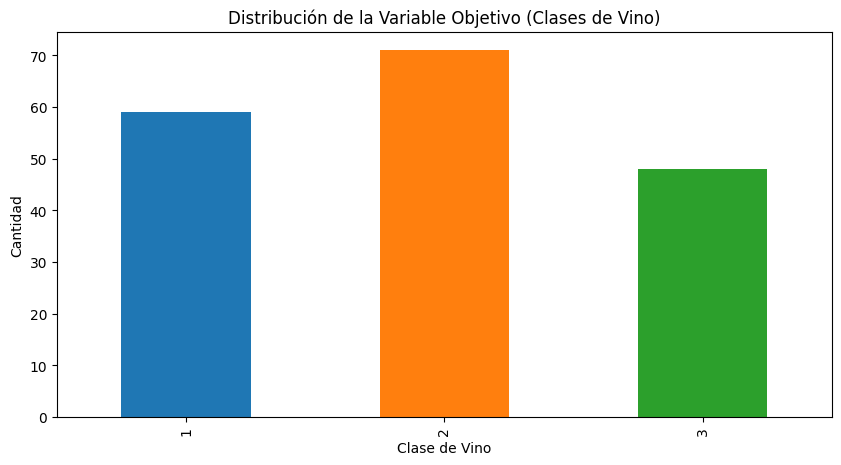

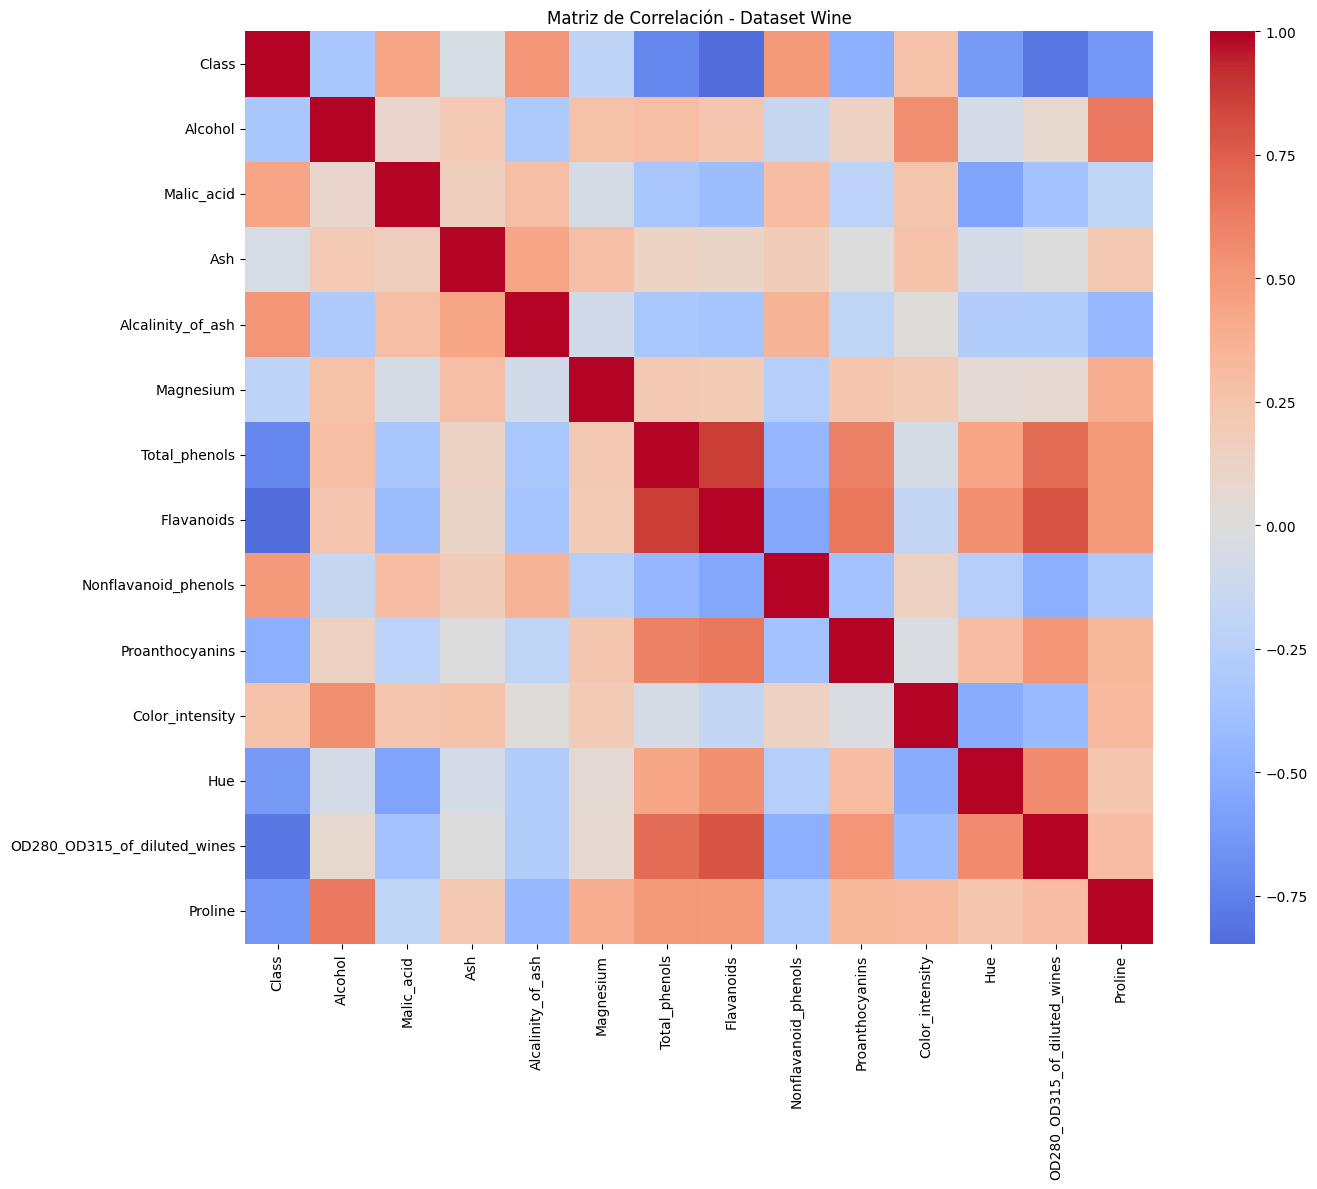


Correlaciones más altas con la variable Class:
Class                           1.000000
Alcalinity_of_ash               0.517859
Nonflavanoid_phenols            0.489109
Malic_acid                      0.437776
Color_intensity                 0.265668
Ash                            -0.049643
Magnesium                      -0.209179
Alcohol                        -0.328222
Proanthocyanins                -0.499130
Hue                            -0.617369
Proline                        -0.633717
Total_phenols                  -0.719163
OD280_OD315_of_diluted_wines   -0.788230
Flavanoids                     -0.847498
Name: Class, dtype: float64


In [ ]:
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

# Estadísticas descriptivas de las variables
print("Estadísticas descriptivas del dataset:")
print(df.describe())

# Distribución de la variable objetivo (Class)
plt.figure(figsize=(10, 5))
counts = df['Class'].value_counts().sort_index()
counts.plot(kind='bar', color=['#1f77b4', '#ff7f0e', '#2ca02c'])

plt.title('Distribución de la Variable Objetivo (Clases de Vino)')
plt.xlabel('Clase de Vino')
plt.ylabel('Cantidad')

# Matriz de correlación
corr_matrix = df.corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Matriz de Correlación - Dataset Wine')
plt.tight_layout()
plt.show()

print("\nCorrelaciones más altas con la variable Class:")
class_corr = corr_matrix['Class'].sort_values(ascending=False)
print(class_corr)

---

## 2. Design and Training of the Multilayer Neural Network

Una red neuronal multicapa, extiende las capacidades de un modelo de neurona simple al incorporar una o más capas ocultas compuestas por múltiples neuronas. Estas capas adicionales permiten que el modelo aprenda relaciones complejas y no lineales entre las variables de entrada y la variable objetivo (Geeks for Geeks, 2025).

A diferencia de los modelos de una sola neurona, que únicamente pueden representar límites de decisión lineales, las redes neuronales multicapa pueden modelar fronteras de decisión no lineales gracias al uso de múltiples capas y funciones de activación. Esto las hace más adecuadas para problemas reales, donde las relaciones entre variables suelen ser más complejas.

### 2.1 Train/Validation/Test Split

Para preparar los datos separamos las características del dataset (X) y la variable objetivo (y).

Después, el dataset lo dividimos en tres subconjuntos: entrenamiento, validación y prueba. Utilizamos dos veces la función `train_test_split()`. Primero asignandole el 20% de los datos al conjunto de prueba, y el 80% restante lo dividimos de nuevo en 75% para entrenamiento y 25% para validación. El resultado es una distribución aproximada de 60% entrenamiento, 20% validación y 20% prueba.

Además, utilizamos el parámetro `stratify` para asegurar que la proporción de clases se mantenga similar en todos los subconjuntos, esto con el fin de evitar sesgos en la distribución de los datos. También definimos `random_state=42` para garantizar que la división sea reproducible.

Después de realizar la división de los datos en los conjuntos de entrenamiento, validación y prueba, verificamos que se hubiera realizado correctamente. Analizamos los tamaños de cada conjunto, tanto en número de muestras como en porcentaje respecto al total, así pudimos confirmar que las proporciones fueran las esperadas.

Asimismo, revisamos la distribución de las clases dentro de cada conjunto, comprobando que las proporciones de cada clase se mantienen similares.

### 2.2 Feature Standardization

De acuerdo con lo que analizamos en las estadísticas descriptivas, observamos que las variables presentan diferentes rangos y desviaciones estándar. Esto indica que las características no están en la misma escala, así que se necesita aplicar un proceso de estandarización.

La estandarización transforma cada característica para que tenga una media cercana a 0 y una desviación estándar cercana a 1. Esto ayuda mucho a que los optimizadores gradiente descente (como Adam) funcionen de manera eficiente y coherente en todas las características.

Utilizamos `StandardScaler()` para lograr esta transformación, ajustándolo únicamente con los datos de entrenamiento (`X_train`). La transformación aprendida la aplicamos a los conjuntos de validación (`X_val`) y prueba (`X_test`).

Después de esto, realizamos una verificación para asegurar que este se haya aplicado correctamente. Calculamos la media y la desviación estándar de las variables en el conjunto de entrenamiento que tenrían que arrojar 0 y 1 respectivamente.

In [ ]:
# Separar características (X) y objetivo (y)
X = df.drop('Class', axis=1)  # 13 características
y = df['Class']                # Variable objetivo

# Primera división: 20% para test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Segunda división: dividir el 80% restante en 75% train y 25% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("Tamaños de los conjuntos:")
print(f"Training set: {X_train.shape[0]} muestras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} muestras ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} muestras ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nDistribución de clases en cada conjunto:")
print("\nEntrenamiento:")
print(y_train.value_counts(normalize=True).sort_index())
print("\nValidación:")
print(y_val.value_counts(normalize=True).sort_index())
print("\nPrueba:")
print(y_test.value_counts(normalize=True).sort_index())

# Estandarizar features usando StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nRevisión de Estandarización")
print(f"Media de features (train): {X_train_scaled.mean(axis=0).round(4)}")
print(f"Desviación estándar (train): {X_train_scaled.std(axis=0).round(4)}")

Tamaños de los conjuntos:
Training set: 106 muestras (59.6%)
Validation set: 36 muestras (20.2%)
Test set: 36 muestras (20.2%)

Distribución de clases en cada conjunto:

Entrenamiento:
Class
1    0.330189
2    0.405660
3    0.264151
Name: proportion, dtype: float64

Validación:
Class
1    0.333333
2    0.388889
3    0.277778
Name: proportion, dtype: float64

Prueba:
Class
1    0.333333
2    0.388889
3    0.277778
Name: proportion, dtype: float64

Revisión de Estandarización
Media de features (train): [ 0. -0.  0.  0.  0. -0. -0. -0. -0.  0. -0.  0. -0.]
Desviación estándar (train): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### 2.3 Model architecture

Para este trabajo utilizaremos TensorFlow/Keras para construir una red neuronal multicapa. A diferencia de una red simple con una sola capa oculta, esta arquitectura tiene múltiples capas densas con funciones de activación no-lineales que permiten aprender patrones más complejos en los datos (Geeks for Geeks, 2025).

La estructura del modelo general es:
- **Capa de entrada:** recibe las 13 características del dataset
- **Capas ocultas:** múltiples capas densas con activación ReLU
- **Capa de salida:** softmax para generar probabilidades de las 3 clases

**ReLU en las capas ocultas:**
ReLU es una función simple pero efectiva: si x < 0 devuelve 0, si no devuelve el valor de x. Introduce no-linealidad en el modelo, lo que permite aprender representaciones complejas (Geeks for Geeks, 2026).

**Softmax en la salida:**
La activación softmax normaliza los valores de salida en probabilidades que suman 1. Esto es conveniente para problemas de clasificación multiclase como el nuestro con 3 clases (Geeks for Geeks, 2026).

---

## 3. Hyperparameter optimisation (2.6)

### 3.1 Hyperparameter Optimisation Methods

Como paso 2.6 del diseño y entrenamiento del modelo, se encuentra la optimización de hiperparámetros (inciso 3 de la tarea). Este es un paso crítico en el desarrollo de modelos de aprendizaje, ya que el desempeño del modelo puede variar significativamente dependiendo de los valores seleccionados.

Aunque es posible definir los hiperparámetros de forma manual con base en la intuición, este enfoque no siempre garantiza obtener los mejores resultados, por lo que resulta necesario realizar un proceso de optimización adecuado.

Para esta tarea, compararemos y eligiremos entre los métodos de búsqueda aleatoria (random search) y optimización bayesiana (Bayesian optimization).

**Búsqueda Aleatoria (Random Search)**

Es uno de los métodos más simples y directos para optimizar hiperparámetros. Consiste en definir rangos para cada hiperparámetro, generar combinaciones aleatorias dentro de esos rangos, entrenar el modelo con cada configuración y evaluar su desempeño en el conjunto de validación. Al final, se elige la configuración que obtiene el mejor resultado (Shah, 2025).

**Optimización Bayesiana (Bayesian Optimization)**

La optimización bayesiana es un método más avanzado para la selección de hiperparámetros. A diferencia de random search, este método utiliza la información de pruebas anteriores para decidir qué combinaciones probar después. Es decir, que va “aprendiendo” cuáles regiones de búsqueda son mejores y enfoca la exploración en ellas (Shah, 2025).


En base a lo que investigamos, decidimos implementar **random search**, ya que, aunque no aprovecha la información de iteraciones previas, es más sencillo de comprender y explicar.

### 3.2 Aplication of Random Search

Para realizar la optimización de hiperparámetros se implementó, con base en el código visto en clase, el uso de la librería Optuna. En primer lugar, aplicamos one-hot encoding a las etiquetas de entrenamiento, validación y prueba, ajustando las clases de 1–3 a 0–2 para que sean compatibles con la salida del modelo.

Después definimos la función objetivo, la cual nos permite evaluar distintas combinaciones de hiperparámetros. Dentro de esta función se establecen los parámetros a optimizar:

- **Learning rate (lr)**: define la tasa de aprendizaje del modelo. Se configuró en un rango de 1e-4 a 1e-2 en escala logarítmica.
- **Batch size**: corresponde al tamaño del lote de entrenamiento. Se definió como un conjunto discreto de valores (16, 32 y 64), ya que comúnmente estos tamaños siguen potencias de 2 por eficiencia computacional.
- **Número de capas (n_layers)**: determina la cantidad de capas ocultas en la red neuronal. En este caso se estableció un rango de 2 a 4 capas, conforme a lo indicado en las instrucciones.
- **Número de épocas (epochs)**: indica cuántas veces el modelo recorre todo el conjunto de datos durante el entrenamiento. Se definió entre 20 y 60 iteraciones para mantener un balance entre desempeño y tiempo de ejecución.
- **Número de neuronas por capa (units)**: se definió como un único hiperparámetro general aplicado a todas las capas ocultas. Su rango va de 16 a 512 neuronas.

En base a esto construimos el modelo utilizando `tf.keras.Sequential()`. Las capas ocultas se generan de forma dinámica en función del número de capas definido, utilizando el mismo número de neuronas en cada una de ellas, según el hiperparámetro units, y usando la función de activación ReLU.

Posteriormente, definimos la capa de salida con tres neuronas, correspondientes a las tres clases del dataset, utilizando la función de activación `softmax` para obtener probabilidades. El modelo se compila utilizando el optimizador Adam, la métrica de accuracy y la función de pérdida `categorical_crossentropy` (previamente se aplicó one-hot encoding a las etiquetas).

El entrenamiento del modelo se realiza mediante `model.fit`, utilizando los datos de entrenamiento y validación, y configurando `verbose=0` para evitar la impresión de información en consola. Una vez entrenado el modelo, se evalúa su desempeño en el conjunto de validación mediante `model.evaluate`, obteniendo el valor de accuracy, el cual se utiliza como métrica objetivo.

Finalmente, se creamos un estudio en Optuna utilizando la estrategia de Random Search mediante `RandomSampler`, con el objetivo de maximizar la métrica de accuracy. Se ejecutan 20 iteraciones (`n_trials=20`) para explorar distintas combinaciones de hiperparámetros, y al finalizar se reportan los mejores resultados junto con visualizaciones que permiten analizar la importancia de cada hiperparámetro y su interacción.



In [ ]:
# One-hot encoding
y_train_cat = to_categorical(y_train - 1, 3)
y_val_cat = to_categorical(y_val - 1, 3)
y_test_cat = to_categorical(y_test - 1, 3)

# Función objetivo
def objective(trial):
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])
    n_layers = trial.suggest_int("n_layers", 2, 4)
    epochs = trial.suggest_int("epochs", 20, 60)
    units = trial.suggest_int("units", 16, 512)

    model = tf.keras.Sequential()
    for _ in range(n_layers):
        model.add(tf.keras.layers.Dense(units, activation='relu'))
    model.add(tf.keras.layers.Dense(3, activation='softmax'))

    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    model.fit(X_train_scaled, y_train_cat, validation_data=(X_val_scaled, y_val_cat),
              epochs=epochs, batch_size=batch_size, verbose=0)
    return model.evaluate(X_val_scaled, y_val_cat, verbose=0)[1]

study = optuna.create_study(direction="maximize", sampler=optuna.samplers.RandomSampler(seed=42))
print("="*70 + "\nOptimización de Hiperparámetros (20 ensayos)\n" + "="*70)
study.optimize(objective, n_trials=20)

print(f"\nMejor exactitud: {study.best_value:.4f}")
print(study.best_params)

optuna.visualization.plot_param_importances(study).show()
optuna.visualization.plot_parallel_coordinate(study).show()

[I 2026-03-27 04:09:05,000] A new study created in memory with name: no-name-df9d1a31-5ead-4873-ba87-348ead2bbe78


Optimización de Hiperparámetros (20 ensayos)


[I 2026-03-27 04:09:20,792] Trial 0 finished with value: 1.0 and parameters: {'learning_rate': 0.0005611516415334506, 'batch_size': 16, 'n_layers': 2, 'epochs': 26, 'units': 44}. Best is trial 0 with value: 1.0.
[I 2026-03-27 04:09:32,516] Trial 1 finished with value: 0.9722222089767456 and parameters: {'learning_rate': 0.005399484409787433, 'batch_size': 32, 'n_layers': 4, 'epochs': 54, 'units': 121}. Best is trial 0 with value: 1.0.
[I 2026-03-27 04:09:38,794] Trial 2 finished with value: 0.9722222089767456 and parameters: {'learning_rate': 0.0002310201887845295, 'batch_size': 64, 'n_layers': 3, 'epochs': 31, 'units': 320}. Best is trial 0 with value: 1.0.
[I 2026-03-27 04:09:43,663] Trial 3 finished with value: 0.9722222089767456 and parameters: {'learning_rate': 0.00019010245319870352, 'batch_size': 64, 'n_layers': 4, 'epochs': 28, 'units': 271}. Best is trial 0 with value: 1.0.
[I 2026-03-27 04:09:52,668] Trial 4 finished with value: 0.9722222089767456 and parameters: {'learning_r


Mejor exactitud: 1.0000
{'learning_rate': 0.0005611516415334506, 'batch_size': 16, 'n_layers': 2, 'epochs': 26, 'units': 44}


### 3.2 Details of Random Search

En este caso decidimos utilizar 20 intentos de optimización dentro del random search, ya que, considerando la naturaleza aleatoria de este método, nuestra intención es explorar distintas combinaciones de hiperparámetros sin requerir un número excesivamente grande de iteraciones. Identificando configuraciones que ofrecieran un buen desempeño, pero que al mismo tiempo implicaran un menor costo computacional, es decir, evitando el uso innecesario de muchas capas o un número muy elevado de neuronas.

A partir de los resultados obtenidos, se considera que los hiperparámetros que encontramos son adecuados. Al analizar la gráfica de importancia de hiperparámetros generada al usar Optuna, observamos que el factor más influyente es el número de neuronas por capa, seguido del learning rate, el número de épocas, el batch size y, finalmente, el número de capas. Esto indica que, aunque incrementar el número de neuronas puede aumentar el costo computacional, no es necesario utilizar una gran cantidad de capas o un batch size elevado para obtener un buen desempeño.

En particular, el modelo óptimo encontrado presenta un número reducido de capas (2 capas ocultas), lo cual ayuda a mantener la complejidad del modelo controlada. Aunque el número de neuronas por capa puede ser relativamente alto, el uso de un batch size pequeño permite compensar este incremento, logrando un equilibrio entre precisión y eficiencia.

Por otro lado, el parallel coordinate plot permite observar cómo interactúan los distintos hiperparámetros. A partir de esta visualización, se puede notar que los parámetros que tienen mayor impacto en el resultado final son principalmente el número de neuronas por capa y el learning rate. En contraste, otros hiperparámetros como el número de capas, el número de épocas y el batch size muestran una mayor flexibilidad, ya que es posible obtener valores altos de accuracy sin necesidad de ajustarlos a valores extremos.

En general, estos resultados nos demuestran que no todos los hiperparámetros tienen el mismo nivel de influencia en el desempeño del modelo, y que es posible encontrar configuraciones eficientes enfocándose principalmente en aquellos que tienen mayor impacto.

---

### 2.4 Loss function

Para el entrenamiento del modelo utilizamos la función de pérdida *categorical crossentropy*, la cual es adecuada para problemas de clasificación multiclase cuando las etiquetas se encuentran codificadas en formato *one-hot*. Esto se implementa en la compilación del modelo: `loss='categorical_crossentropy'`

### 2.5 Optimiser

El optimizador seleccionado es Adam (según lo recomendado en las instrucciones); sin embargo, la tasa de aprendizaje no es fija, sino que proviene del proceso de optimización de hiperparámetros:

`optimizer=keras.optimizers.Adam(learning_rate=best_hp['learning_rate'])`

### 2.6 Hyperparameter optimisation

Después de completar la optimización con Optuna, la mejor configuración de hiperparámetros encontrada la utilizamos para construir y entrenar el modelo final. Este modelo se entrena con el conjunto completo de entrenamiento y se valida con el conjunto de validación.

### 2.7 Neural network training
El entrenamiento del modelo se realiza utilizando los datos previamente escalados (`X_train_scaled, X_val_scaled`) y las etiquetas en formato categórico (`y_train_cat, y_val_cat`).

El número de épocas y el tamaño de lote provienen de la optimización de hiperparámetros que realizamos anteriormente, lo cual permite que el entrenamiento sea más eficiente y adaptado al dataset.

Además, se utiliza un conjunto de validación para monitorear el desempeño del modelo durante el entrenamiento y evitar el sobreajuste por medio de Early Stopping.

## 4. Early Stopping

Según lo que vimos en clases, el *Early Stopping* es una técnica de regularización que detiene automáticamente el entrenamiento cuando el desempeño en el conjunto de validación deja de mejorar. Esto previene que el modelo se sobreajuste (overfitting) a los datos de entrenamiento.

La paciencia de 6 épocas permite que el modelo siga intentando mejorar durante varios intentos fallidos, antes de asumir que ha convergido. Un valor muy bajo causaría parada prematura, mientras que uno muy alto permitiría sobreajuste.

In [ ]:
# Obtener los mejores hiperparámetros encontrados
best_hp = study.best_params

print("="*70)
print("Construyendo modelo final con hiperparámetros óptimos...")
print("="*70)
print(f"Tasa de aprendizaje: {best_hp['learning_rate']:.6f}")
print(f"Tamaño de lote: {best_hp['batch_size']}")
print(f"Número de capas: {best_hp['n_layers']}")
print(f"Unidades por capa: {best_hp['units']}")
print(f"Épocas: {best_hp['epochs']}")
print("="*70)

# Construir modelo final
final_model = keras.Sequential()

for i in range(best_hp['n_layers']):
    final_model.add(layers.Dense(
        best_hp['units'],
        activation='relu',
        input_shape=(13,) if i == 0 else None
    ))

# Capa de salida
final_model.add(layers.Dense(3, activation='softmax'))

# Compilar
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=best_hp['learning_rate']),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nArquitectura del modelo final:")
final_model.summary()

# Early Stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

history = final_model.fit(
    X_train_scaled, y_train_cat,
    epochs=best_hp['epochs'],
    batch_size=best_hp['batch_size'],
    validation_data=(X_val_scaled, y_val_cat),
    callbacks=[early_stopping],
    verbose=1
)

print(f"\nEntrenamiento completado en {len(history.history['loss'])} épocas")


Construyendo modelo final con hiperparámetros óptimos...
Tasa de aprendizaje: 0.000561
Tamaño de lote: 16
Número de capas: 2
Unidades por capa: 44
Épocas: 26

Arquitectura del modelo final:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_82 (Dense)                │ (None, 44)             │           616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 44)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 3)              │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,731 (10.67 KB)

 Trainable params: 2,731 (10.67 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/26
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.6509 - loss: 0.8702 - val_accuracy: 0.6944 - val_loss: 0.8353
Epoch 2/26
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7170 - loss: 0.7848 - val_accuracy: 0.8056 - val_loss: 0.7574
Epoch 3/26
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8679 - loss: 0.7076 - val_accuracy: 0.8889 - val_loss: 0.6841
Epoch 4/26
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9057 - loss: 0.6358 - val_accuracy: 0.9444 - val_loss: 0.6160
Epoch 5/26
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9340 - loss: 0.5690 - val_accuracy: 0.9444 - val_loss: 0.5527
Epoch 6/26
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9623 - loss: 0.5072 - val_accuracy: 0.9444 - val_loss: 0.4943
Epoch 7/26
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9717 - loss: 0.4504 - val_accuracy: 0.9444 - val_loss: 0.4408
Epoch 8/26
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9906 - loss: 0.3985 - val_accuracy: 0.9722 - val_loss: 0.3923


---

## 5. Learning Curve Analysis

Las curvas de aprendizaje son herramientas visuales fundamentales para diagnosticar el estado de ajuste de un modelo. Al graficar la precisión y pérdida tanto en el conjunto de entrenamiento como en el de validación a través de las épocas, podemos identificar patrones que indican: Overffitng, Underfitting y Appropriate Fitting.

Para este inciso, graficaremos tanto la exactitud (accuracy) como la pérdida (loss) para obtener una visión completa del desempeño.

Para generar estas gráficas, se utilizó matplotlib creando una figura con dos subgráficas en una misma fila `(fig, axes = plt.subplots(1, 2, figsize=(14, 4)))`.

En la primera subgráfica `(axes[0])`, se muestra la evolución de la pérdida a lo largo de las épocas. Para esto, se grafican los valores de entrenamiento `(history.history['loss'])` y de validación `(history.history['val_loss'])`, permitiendo observar cómo el modelo va ajustándose durante el entrenamiento.

En la segunda subgráfica `(axes[1])`, se presenta la evolución de la exactitud, siguiendo el mismo enfoque con `history.history['accuracy']` y `history.history['val_accuracy']`.

Adicionalmente, se agregan títulos, etiquetas en los ejes, leyendas y una cuadrícula para hacer más clara la interpretación de las gráficas. Finalmente, con `plt.tight_layout()` se ajusta el espaciado entre las subgráficas y con `plt.show()` se despliega la figura.

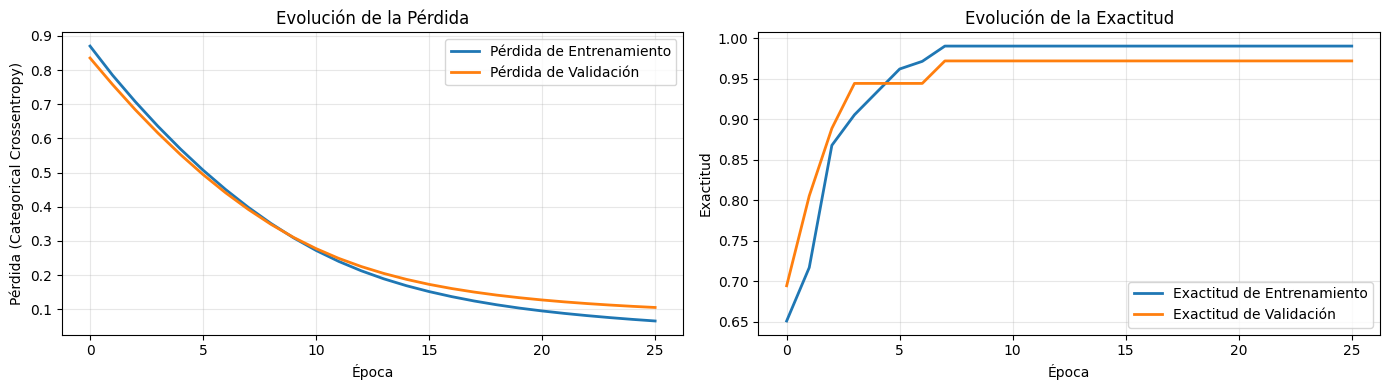

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Pérdida en entrenamiento y validación
axes[0].plot(history.history['loss'], label='Pérdida de Entrenamiento', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Pérdida de Validación', linewidth=2)
axes[0].set_title('Evolución de la Pérdida')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida (Categorical Crossentropy)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Exactitud en entrenamiento y validación
axes[1].plot(history.history['accuracy'], label='Exactitud de Entrenamiento', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Exactitud de Validación', linewidth=2)
axes[1].set_title('Evolución de la Exactitud')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Exactitud')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Como podemos apreciar en las gráficas de pérdida y exactitud, se presenta un patrón de un modelo con appropriate fitting. Esto se puede distinguir ya que, en ambas métricas, las curvas de entrenamiento y validación se mantienen cercanas entre sí a lo largo de las épocas, sin mostrar una separación significativa.

Además, la pérdida disminuye de manera consistente en ambos conjuntos, lo que indica que el modelo está aprendiendo correctamente, mientras que la exactitud alcanza valores altos tanto en entrenamiento como en validación. Aunque la exactitud de entrenamiento es ligeramente superior, la diferencia no es considerable, lo cual sugiere una buena capacidad de generalización.

---

## 6. Model Evaluation and Testing Data

Después de entrenar y validar el modelo, procederemos a evaluar su desempeño en el conjunto de prueba, que es completamente independiente de los datos utilizados durante el entrenamiento y validación.


### 6.1 Metrics

Como primer método de evaluación de los resultados del conjunto de prueba, utilizaremos métricas de desempeño para tener una visión más completa del desempeño del modelo.

Primero, se generan las predicciones a partir del modelo con `final_model.predict(X_test_scaled, verbose=0)`. Después, se evalúa directamente el modelo sobre el conjunto de prueba mediante `final_model.evaluate(X_test_scaled, y_test_cat, verbose=0)`, obteniendo los valores de pérdida y accuracy.

Adicionalmente, se calculan métricas como precisión, recall y F1-score utilizando `precision_score`, `recall_score` y `f1_score`, respectivamente. En todos los casos se emplea el parámetro `average='weighted'`, lo que nos permite considerar el posible desbalance entre clases al hacer las ponderaciones.

En este caso no se calculó la especificidad ya que esta se considera más una metrica para modelos de clasificación binaria.

### 6.2 Confusion Matrix

Como complemento a las métricas anteriores, construimos una matriz de confusión con el fin de visualizar de manera más clara el comportamiento del modelo en el conjunto de prueba. Esta se obtiene mediante `confusion_matrix(y_test, y_test_pred)`, comparando directamente las clases reales con las predicciones generadas.

Para tener una mejor visualización, utilizamos `sns.heatmap()`, donde cada fila corresponde a la clase real y cada columna a la clase predicha. Los valores en la diagonal principal representan las predicciones correctas, mientras que los valores fuera de esta indican errores de clasificación entre clases.

Además, se configuran etiquetas para los ejes (Clase 1, Clase 2, Clase 3), junto con un título y ajustes de formato mediante `plt.tight_layout()` para mejorar la visualización.

Pérdida: 0.1024 | Accuracy: 0.9722
Precision: 0.9741 | Recall: 0.9722 | F1: 0.9720


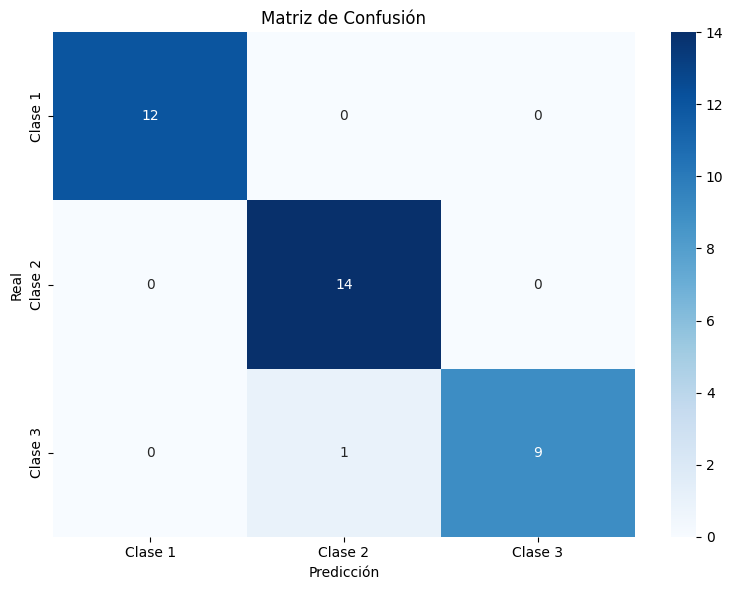

In [ ]:
# Predicciones
y_test_pred = np.argmax(final_model.predict(X_test_scaled, verbose=0), axis=1) + 1

# Evaluación
test_loss, test_accuracy = final_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f"Pérdida: {test_loss:.4f} | Accuracy: {test_accuracy:.4f}")

# Métricas
precision = precision_score(y_test, y_test_pred, average='weighted')
recall = recall_score(y_test, y_test_pred, average='weighted')
f1 = f1_score(y_test, y_test_pred, average='weighted')


print(f"Precision: {precision:.4f} | Recall: {recall:.4f} | F1: {f1:.4f}")

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Clase 1', 'Clase 2', 'Clase 3'], yticklabels=['Clase 1', 'Clase 2', 'Clase 3'])
plt.title('Matriz de Confusión')
plt.ylabel('Real')
plt.xlabel('Predicción')
plt.tight_layout()
plt.show()

Como se puede ver, obtuvimos resultados de clasificación multiclase bastante sólidos. La exactitud de 0.9722, junto con valores altos de precisión (0.9741), recall (0.9722) y F1-score (0.9720), indican que el modelo no solo clasifica correctamente la mayoría de las muestras, sino que también mantiene un buen equilibrio entre identificar correctamente las clases y evitar falsos positivos. Además, la baja pérdida (0.1024) nos dice que el modelo logró una buena convergencia durante el entrenamiento y que generaliza adecuadamente sobre datos no vistos.

Por otro lado, al analizar la matriz de confusión, se puede observar que el modelo clasifica de manera perfecta, en este conjunto de prueba, las clases 1 y 2. En el caso de la clase 3, únicamente se presenta un error, donde una muestra es clasificada como clase 2.

En general, el comportamiento del modelo es consistente con un ajuste adecuado (appropriate fitting), ya que mantiene un alto desempeño en todas las clases sin evidencia clara de sobreajuste ni sesgo hacia alguna clase en particular.

---

## 7. Save the Model

Como último paso de la tarea, guardamos el modelo entrenado en un archivo para poder reutilizarlo posteriormente. Para esto, definimos el nombre del archivo (`wine_optimized.keras`) y se guarda el modelo utilizando `final_model.save(archivo_modelo)`. Posteriormente, el modelo lo volvemos a cargar con keras.`models.load_model(archivo_modelo)` con el fin de verificar que el guardado se realizó correctamente. Finalmente, se imprime el resumen tanto del modelo original  como del modelo cargado para comprobar que la arquitectura y los parámetros se conservaron adecuadamente.

El guardado de los modelos es importante en la práctica para poder reutilizarlos sin necesidad de volver a entrenarlos, permitiendo analizarlos o implementarlos de manera más eficiente.

In [ ]:
 # Guardar el modelo
import os

archivo_modelo = 'wine_optimized.keras'
final_model.save(archivo_modelo)

# Cargar y verificar
modelo_verificado = keras.models.load_model(archivo_modelo)

print("\nResumen del Modelo Original (final_model)")
final_model.summary()

print("\nResumen del Modelo Cargado (modelo_verificado)")
modelo_verificado.summary()


Resumen del Modelo Original (final_model)


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_82 (Dense)                │ (None, 44)             │           616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 44)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 3)              │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,195 (32.02 KB)

 Trainable params: 2,731 (10.67 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_82 (Dense)                │ (None, 44)             │           616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_83 (Dense)                │ (None, 44)             │         1,980 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_84 (Dense)                │ (None, 3)              │           135 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,195 (32.02 KB)

 Trainable params: 2,731 (10.67 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,464 (21.35 KB)

Al revisar los resúmenes de la arquitectura del modelo original y el modelo cargado pudimos verificar que el modelo se guardó sin problemas.

---

## Conclusiones Personales
*Perla Antonio*

Desde una perspectiva personal, esta actividad facilitó la comprensión del proceso del desarrollo completo del proceso de un modelo de machine learning, es decir, desde el momento inicial en el que se analiza la información hasta el de evaluación del modelo.

Uno de los principales aprendizajes fue la importancia del preprocesamiento (especialmente de la estandarización de las variables y de cómo se separan los datos). Se pudo observar cómo estos pasos en particular influyen directa y positivamente en el rendimiento del modelo y su capacidad de generalizar correctamente sobre nuevos datos.

Del mismo modo, la introducción de una red neuronal multicapa permitió comprender cómo los modelos pueden captar relaciones que no sean lineales entre las variables, consiguiendo así un alto rendimiento en la tarea de clasificación. También resultó muy interesante la posibilidad de emplear técnicas como, por ejemplo, la optimización de hiperparámetros mediante Optuna, ya que pudo evidenciar cómo las configuraciones de los modelos pueden aportar mejoras significativas en los resultados finales del modelo.

El análisis de las curvas de aprendizaje bajo la cual se ejercita el modelo fue decisivo para interpretar el comportamiento que presenta este modelo de machine learning mientras va siendo entrenado (permite detectar que el modelo está suficientemente ajustado y no muestra señales evidentes de sobreajuste o de subajuste).

Por otro lado, se pudo notar que, aun cuando el modelo puede llegar a conseguir una predicción extremadamente elevada (en el contexto de una alta precisión), hay siempre algún grado de error en las clasificaciones a pesar de todo; ya que los modelos de machine learning no son perfectos sino que siempre existe un margen de mejora.

*María Elisa*

En conclusión, esta tarea colaborativa me ayudó mucho a comprender con mayor detalle las redes neuronales multicapa. Uno de los principales aprendizajes que me llevé fue la experiencia de implementar la optimización de hiperparámetros, ya que nunca la había trabajado. En proyectos pasados, tenía que hacer pruebas de ensayo y error con modelos pesados para identificar qué parámetros tenían mayor efecto y en qué medida impactaban, por lo que me pareció muy interesante implementarlo en la MLP.

Uno de los retos que enfrenté fue entender cómo, en ciertos casos, algunos hiperparámetros no afectan tanto el resultado. Yo estaba acostumbrada a que, si una red neuronal no tenía un buen desempeño, simplemente le agregaba más capas; sin embargo, ahora comprendí que todo depende del modelo, de la importancia de los hiperparámetros y de cómo, con herramientas como las visualizaciones de Optuna, podemos sacrificar ligeramente la métrica objetivo a cambio de tener una red más simple y eficiente.

Sobre el entrenamiento de redes neuronales, en este caso multicapa, aprendí que permiten modelar relaciones no lineales, lo que da lugar a resultados muy positivos. Además, en combinación con la optimización de hiperparámetros, se convierten en una herramienta muy fuerte para lograr un buen balance entre desempeño y eficiencia.

Me sorprendió mucho que la red alcanzara métricas de desempeño extremadamente buenas con muy pocas capas ocultas y con pocas épocas. En este caso, el early stopping no se activó, ya que el modelo completó las 26 épocas establecidas sin presentar deterioro en la métrica de validación.

En general, esta tarea me sirvió mucho para combinar los conocimientos vistos en clase con los que ya tenía de IA 1, logrando así construir modelos multicapa más efectivos y optimizados.

*Sergio Zamora*

Esta actividad fue bastante útil para poder entender el cómo el proceso de crear un modelo de machine learning cambia al optimizar hiperparámetros. Además de que me di cuenta de que desde preparar los datos hasta evaluar los resultados finales, cada paso es de gran importancia.

Lo que más me llamó la atención fueron los detalles como la estandarización de los datos y la forma en la que dividimos los datos en entrenamiento, validación y prueba. Estos detalles impactan mucho en cómo el modelo aprende. También aprendí hacerca de no obsesionarse con una arquitectura super complicada, ya que en esta tarea la red neuronal con 2-4 capas funcionó muy bien.

Usar Optuna para buscar los mejores hiperparámetros fue interesante, y al ver las curvas de aprendizaje me ayudó a entender que el modelo llegó al resultado esperado, un modelo bien ajustado.

El resultado final con 97% de exactitud es un buen resultado. Aunque no es perfecto, pero demuestra que al esforzarse en el trabajo de preparación y si se elige bien la configuración, los resultados mejoran bastante.

## Repositorio GitHub
*Perla Antonio*

https://github.com/perlaantonio-cmd/-Multilayer-neural-network-with-hyperparameter-optimisation


*María Elisa*

https://mariae-olivares.github.io/Assignment-6-Multilayer-neural-network-with-hyperparameter-optimisation-/

https://github.com/mariae-olivares/Assignment-6-Multilayer-neural-network-with-hyperparameter-optimisation-

*Sergio*

https://github.com/SaZ03/Assignment-6-Multilayer-neural-network-with-hyperparameter-optimisation-

## Referencias

Geeks for Geeks. (2025, 30 septiembre). Aprendizaje de perceptrón multicapa en Tensorflow. Geeks For Geeks. https://www.geeksforgeeks.org/deep-learning/multi-layer-perceptron-learning-in-tensorflow/

Geeks for Geeks. (2026, 20 febrero). Funciones de activación en redes neuronales. Geeks For Geeks. https://www.geeksforgeeks.org/machine-learning/activation-functions-neural-networks/

Shah, M. (2025, 19 febrero). A practical guide to hyperparameter tuning: grid search, random search & Bayesian optimization explained ! Medium. https://medium.com/@mdshah930/a-practical-guide-to-hyperparameter-tuning-grid-search-random-search-bayesian-optimization-f0946fbcbbc6

*"Damos nuestra palabra que hemos realizado esta actividad con integridad académica."*